We Are Predicting Whether The Passenger Was Surivived or Not

In [86]:
import pandas as pd
import numpy as np

In [87]:
df=pd.read_csv('/content/Titanic.csv')

In [88]:
df.head(45)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [89]:
df.shape

(418, 12)

In [90]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [91]:
df['Name'].value_counts()

,count
Name,
"Peter, Master. Michael J",1
"Kelly, Mr. James",1
"Hipkins, Mr. William Edward",1
"Asplund, Master. Carl Edgar",1
"O'Connor, Mr. Patrick",1
...,...
"Svensson, Mr. Johan Cervin",1
"Connolly, Miss. Kate",1
"Caldwell, Mr. Albert Francis",1


HANDLING MISSING VALUES

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [93]:
df['Sex'].value_counts()

,count
Sex,
male,266
female,152


SEX are encoded from categorical to numerical values

In [94]:
df['Sex']=df['Sex'].replace({'male':0,'female':1})

/tmp/ipython-input-2165621296.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex']=df['Sex'].replace({'male':0,'female':1})


In [95]:
df['Ticket'].value_counts()


,count
Ticket,
PC 17608,5
CA. 2343,4
113503,4
SOTON/O.Q. 3101315,3
220845,3
...,...
350045,1
371362,1
368783,1


In [96]:
df['Cabin'].value_counts()

,count
Cabin,
B57 B59 B63 B66,3
B45,2
C23 C25 C27,2
C78,2
C31,2
...,...
B41,1
C7,1
D40,1


In [97]:
df['Embarked'].value_counts()

,count
Embarked,
S,270
C,102
Q,46


EMBARKED  are encoded from categorical to numerical values

In [98]:
df['Embarked']=df['Embarked'].replace({'S':0,'C':1,'Q':2})

/tmp/ipython-input-2761887535.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked']=df['Embarked'].replace({'S':0,'C':1,'Q':2})


In [99]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


AGE are filled by mean values

In [100]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipython-input-694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


FARE are filled by mean values

In [101]:
df['Fare'].fillna(df['Fare'].median(),inplace=True)

/tmp/ipython-input-1007884036.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].median(),inplace=True)


In [102]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    int64  
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 39.3+ KB




* NAME is dropped due to all categorical values

* CABIN is dropped due to high missing percentage




In [104]:
x=df.drop(columns=["Survived","Name","Cabin","Ticket"])
y=df['Survived']

In [105]:
print(x)
print(y)

     PassengerId  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0            892       3    0  34.50000      0      0    7.8292         2
1            893       3    1  47.00000      1      0    7.0000         0
2            894       2    0  62.00000      0      0    9.6875         2
3            895       3    0  27.00000      0      0    8.6625         0
4            896       3    1  22.00000      1      1   12.2875         0
..           ...     ...  ...       ...    ...    ...       ...       ...
413         1305       3    0  30.27259      0      0    8.0500         0
414         1306       1    1  39.00000      0      0  108.9000         1
415         1307       3    0  38.50000      0      0    7.2500         0
416         1308       3    0  30.27259      0      0    8.0500         0
417         1309       3    0  30.27259      1      1   22.3583         1

[418 rows x 8 columns]
0      0
1      1
2      0
3      0
4      1
      ..
413    0
414    1
415    0
416    

EDA{Exploratory Data Analysis}

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

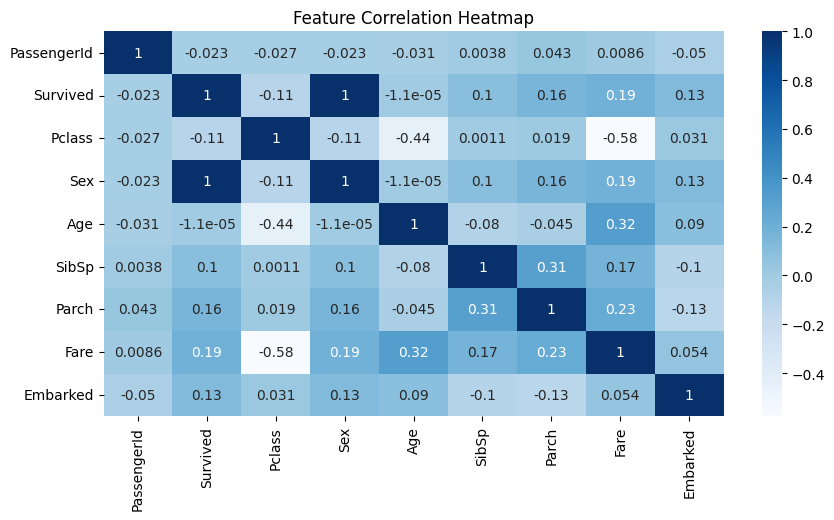

In [107]:

numerical_df=df.select_dtypes(include=np.number)
corr=numerical_df.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,cmap='Blues')
plt.title("Feature Correlation Heatmap")
plt.show()

- Survival is strongly correlated with Sex and Passenger Class
- Fare also has a positive influence on survival


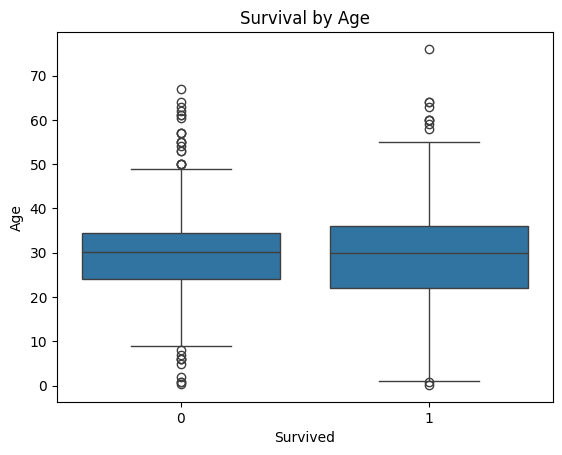

In [108]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Survival by Age")
plt.show()


younger people have higher survival rate compared to elder ones

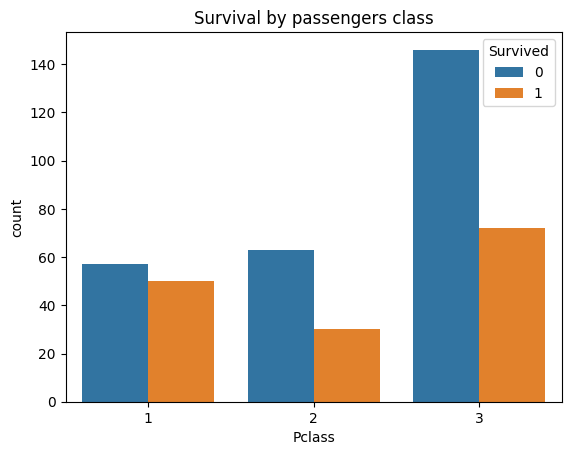

In [109]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by passengers class")
plt.show()

Higher PassengerClass had significantly higher survival rate especially for womens

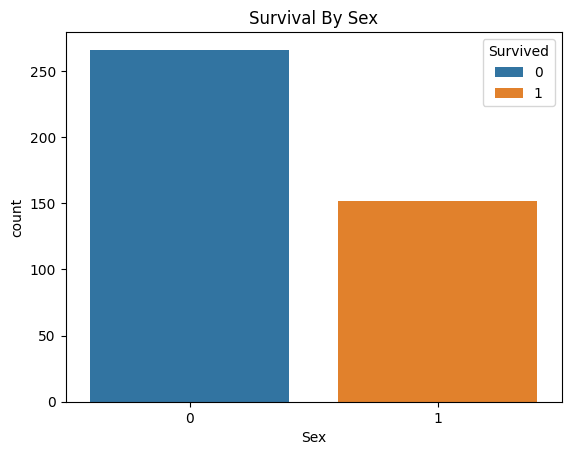

In [110]:

sns.countplot(x='Sex',hue='Survived',data=df)
plt.title("Survival By Sex")
plt.show()

Females had significantly higher survival rate
compared to males

Training ML Models

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [113]:
x.shape,x_train.shape,x_test.shape

((418, 8), (334, 8), (84, 8))

In [114]:
model=LogisticRegression()

In [115]:
training_data=model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [116]:
x_train_predict=model.predict(x_train)
training_data_acccuracy=accuracy_score(x_train_predict,y_train)

In [117]:
print("Accuracy on training data :",training_data_acccuracy)

Accuracy on training data : 1.0


In [118]:
x_test_predict=model.predict(x_test)
test_data_acccuracy=accuracy_score(x_test_predict,y_test)

In [119]:
print("Accuracy on test data :",test_data_acccuracy)

Accuracy on test data : 1.0


In [120]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [121]:
model1=SVC()

In [122]:
training_data=model1.fit(x_train,y_train)

In [123]:
X_train_predict=model1.predict(x_train)
Training_data_accuracy=accuracy_score(X_train_predict,y_train)


In [124]:
print("Accuracy for SVC on training data:",Training_data_accuracy)

Accuracy for SVC on training data: 0.6437125748502994


In [125]:
X_test_predict=model1.predict(x_test)
Testing_data_accuracy=accuracy_score(X_test_predict,y_test)


In [126]:
print("Accuracy for SVC on testing data:",Testing_data_accuracy)

Accuracy for SVC on testing data: 0.6071428571428571


In [127]:
model2=RandomForestClassifier()

In [128]:
train_data=model2.fit(x_train,y_train)

In [129]:
train_data_predict=model2.predict(x_train)
train_data_accuracy=accuracy_score(train_data_predict,y_train)

In [130]:
print("Accuracy for RandomForest  on training data:",train_data_accuracy*100)

Accuracy for RandomForest  on training data: 100.0


In [131]:
test_data_predict=model2.predict(x_test)
test_data_accuracy=accuracy_score(test_data_predict,y_test)

In [132]:
print("Accuracy for RandomForest  on testing data:",test_data_accuracy*100)

Accuracy for RandomForest  on testing data: 100.0


In [133]:
x_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
280,1172,3,1,23.0,0,0,8.6625,0
284,1176,3,1,2.0,1,1,20.2125,0
40,932,3,0,39.0,0,1,13.4167,1
17,909,3,0,21.0,0,0,7.2250,1
362,1254,2,1,31.0,0,0,21.0000,0


| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 100%     |
| svm                 | 64%      |
|Random Forest        | 100%     |


PREDICTION(Survival Outcome)

In [134]:
input_data=(9,32,3,0,39.0,0,1,1)

In [135]:
input_data_as_numpy=np.asarray(input_data)

In [136]:
input_data_reshaped=input_data_as_numpy.reshape(1,-1)

In [137]:
print("Prediction by LogisticRegression")
prediction=model.predict(input_data_reshaped)
print(prediction)

if prediction[0]==0:
  print("Dead")
else:
  print("Alive")

Prediction by LogisticRegression
[1]
Alive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [138]:
print("Prediction by svm SVC")
prediction=model1.predict(input_data_reshaped)
print(prediction)
if prediction[0]==0:
  print("Dead")
else:
  print("Alive")

Prediction by svm SVC
[0]
Dead


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [139]:
print("Prediction by Random Forest")
prediction=model2.predict(input_data_reshaped)
print(prediction)

if prediction[0]==0:
  print("Dead")
else:
  print("Alive")

Prediction by Random Forest
[1]
Alive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Logistic Regression & Random Forest are performed very well with 100% Accuracy